# **Market Basket Analysis with Python - Amazon**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [12]:
df = pd.read_csv(r"E:\RIYA\DATA_SCIENCE\PROJECTS\PYTHON\Amazon.csv")
print(df)

                           Timestamp  age             Gender  \
0     2023/06/08 7:50:55 PM GMT+5:30   65  Prefer not to say   
1     2023/06/09 9:37:44 AM GMT+5:30   20               Male   
2    2023/06/11 11:26:54 PM GMT+5:30   42               Male   
3     2023/06/08 5:17:10 PM GMT+5:30   65             Others   
4    2023/06/11 10:59:30 PM GMT+5:30   45             Female   
..                               ...  ...                ...   
795   2023/06/07 6:15:10 PM GMT+5:30   26               Male   
796  2023/06/11 11:25:48 PM GMT+5:30   61             Others   
797  2023/06/07 10:21:00 PM GMT+5:30   67             Female   
798   2023/06/10 2:40:34 PM GMT+5:30   19             Others   
799   2023/06/05 8:49:12 PM GMT+5:30   10             Others   

         Purchase_Frequency  \
0    Less than once a month   
1               Once a week   
2               Once a week   
3              Once a month   
4               Once a week   
..                      ...   
795           

In [5]:
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer not to say,Less than once a month,Clothing and Fashion,Yes,Multiple times a day,Keyword,Multiple pages,2,...,Yes,Moderately,No,2,Sometimes,4,4,Competitive prices,better app interface and lower shipping charges,778242
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Filter,First page,3,...,Yes,Heavily,Yes,1,Sometimes,4,5,Quick delivery,Scrolling option would be much better than goi...,193482
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,Keyword,Multiple pages,2,...,Yes,Heavily,Sometimes,5,No,5,3,All the above,Nil,925975
3,2023/06/08 5:17:10 PM GMT+5:30,65,Others,Once a month,Beauty and Personal Care;Clothing and Fashion;...,No,Few times a month,Filter,Multiple pages,2,...,Yes,Occasionally,No,3,Yes,1,2,Quick delivery,Quality of product is very poor according to t...,566872
4,2023/06/11 10:59:30 PM GMT+5:30,45,Female,Once a week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,NaN,First page,5,...,Yes,Rarely,No,2,Yes,1,2,Quick delivery,Irrelevant product suggestions,683642


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype
---  ------                                  --------------  -----
 0   Timestamp                               800 non-null    str  
 1   age                                     800 non-null    int64
 2   Gender                                  800 non-null    str  
 3   Purchase_Frequency                      800 non-null    str  
 4   Purchase_Categories                     800 non-null    str  
 5   Personalized_Recommendation_Frequency   800 non-null    str  
 6   Browsing_Frequency                      800 non-null    str  
 7   Product_Search_Method                   643 non-null    str  
 8   Search_Result_Exploration               800 non-null    str  
 9   Customer_Reviews_Importance             800 non-null    int64
 10  Add_to_Cart_Browsing                    800 non-null    str  
 11  Cart_Completion_Frequency     

#### **Task 1: Data Cleaning and Preparation**

In [7]:
#check duplicate rows
print("Duplicate_Rows: ", df.duplicated().sum())

Duplicate_Rows:  0


In [10]:
#remove extra spaces from column names
df.columns = df.columns.str.strip()

#Display updated column names
print(df.columns)


Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Personalized_Recommendation_Frequency',
       'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Personalized_Recommendation_Frequency', 'Recommendation_Helpfulness',
       'Rating_Accuracy', 'Shopping_Satisfaction', 'Service_Appreciation',
       'Improvement_Areas', 'transaction'],
      dtype='str')


In [11]:
#check missing values
print(df.isnull().sum())

Timestamp                                  0
age                                        0
Gender                                     0
Purchase_Frequency                         0
Purchase_Categories                        0
Personalized_Recommendation_Frequency      0
Browsing_Frequency                         0
Product_Search_Method                    157
Search_Result_Exploration                  0
Customer_Reviews_Importance                0
Add_to_Cart_Browsing                       0
Cart_Completion_Frequency                  0
Cart_Abandonment_Factors                   0
Saveforlater_Frequency                     0
Review_Left                                0
Review_Reliability                         0
Review_Helpfulness                         0
Personalized_Recommendation_Frequency      0
Recommendation_Helpfulness                 0
Rating_Accuracy                            0
Shopping_Satisfaction                      0
Service_Appreciation                       0
Improvemen

In [12]:
#Fill missing categorical values with mode
mode_value = df['Product_Search_Method'].mode()[0]

df['Product_Search_Method'] = df['Product_Search_Method'].fillna(mode_value)

In [4]:
#Standardize gender column
df['Gender'] = df['Gender'].str.strip().str.title()

# Standardize Purchase Frequency column
if 'Purchase_Frequency' in df.columns:
    df['Purchase_Frequency'] = (
        df['Purchase_Frequency']
        .astype(str)
        .str.strip()
        .str.title()
    )

In [9]:
#Convert numerical rating columns to numerical data type
rating_columns = [
    'Customer_Reviews_Importance',
    'Add_to_Cart_Browsing',
    'Cart_Completion_Frequency',
    'Saveforlater_Frequency',
    'Shopping_Satisfaction'
]

for col in rating_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [6]:
print(df.dtypes)

Timestamp                                     str
age                                         int64
Gender                                        str
Purchase_Frequency                            str
Purchase_Categories                           str
Personalized_Recommendation_Frequency         str
Browsing_Frequency                            str
Product_Search_Method                         str
Search_Result_Exploration                     str
Customer_Reviews_Importance                 int64
Add_to_Cart_Browsing                      float64
Cart_Completion_Frequency                 float64
Cart_Abandonment_Factors                      str
Saveforlater_Frequency                    float64
Review_Left                                   str
Review_Reliability                            str
Review_Helpfulness                            str
Personalized_Recommendation_Frequency       int64
Recommendation_Helpfulness                    str
Rating_Accuracy                             int64


In [10]:
# Save cleaned dataset
df.to_csv('Amazon_Cleaned.csv', index=False)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


#### **Task 2: Descriptive Behavior Analysis**

##### Task 2.1: Summarize customer demographics (age, gender distribution)

In [12]:
df = pd.read_csv('Amazon_Cleaned.csv')

print(df.head())

                         Timestamp  age             Gender  \
0   2023/06/08 7:50:55 PM GMT+5:30   65  Prefer Not To Say   
1   2023/06/09 9:37:44 AM GMT+5:30   20               Male   
2  2023/06/11 11:26:54 PM GMT+5:30   42               Male   
3   2023/06/08 5:17:10 PM GMT+5:30   65             Others   
4  2023/06/11 10:59:30 PM GMT+5:30   45             Female   

       Purchase_Frequency                                Purchase_Categories  \
0  Less Than Once A Month                               Clothing and Fashion   
1             Once A Week  Groceries and Gourmet Food;Beauty and Personal...   
2             Once A Week  Groceries and Gourmet Food;Beauty and Personal...   
3            Once A Month  Beauty and Personal Care;Clothing and Fashion;...   
4             Once A Week  Beauty and Personal Care;Clothing and Fashion;...   

  Personalized_Recommendation_Frequency    Browsing_Frequency  \
0                                   Yes  Multiple times a day   
1               

In [14]:
# Age distribution
print(df['age'].describe())

count    800.000000
mean      35.170000
std       18.916485
min        3.000000
25%       19.000000
50%       35.500000
75%       51.000000
max       67.000000
Name: age, dtype: float64


In [15]:
# Gender count
gender_distribution = df['Gender'].value_counts()

print(gender_distribution)

Gender
Male                 209
Others               202
Female               197
Prefer Not To Say    192
Name: count, dtype: int64


In [16]:
purchase_freq = df['Purchase_Frequency'].value_counts()

print(purchase_freq)

Purchase_Frequency
Once A Month              168
Once A Week               159
Multiple Times A Week     159
Few Times A Month         158
Less Than Once A Month    156
Name: count, dtype: int64


##### Task 2.2: Analyze overall purchase frequency and most popular product categories

In [17]:
# Count purchase frequency
purchase_frequency = df['Purchase_Frequency'].value_counts()

# Display results
print(purchase_frequency)

Purchase_Frequency
Once A Month              168
Once A Week               159
Multiple Times A Week     159
Few Times A Month         158
Less Than Once A Month    156
Name: count, dtype: int64


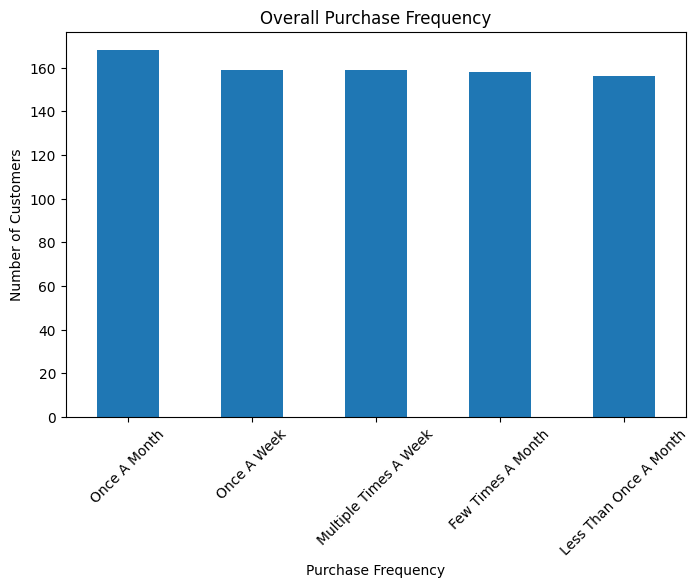

In [20]:
#visualization
plt.figure(figsize=(8,5))

purchase_frequency.plot(kind='bar')

plt.xlabel('Purchase Frequency')
plt.ylabel('Number of Customers')
plt.title('Overall Purchase Frequency')
plt.xticks(rotation=45)

plt.show()

In [19]:
# Count product categories
popular_categories = df['Purchase_Categories'].value_counts()

# Display results
print(popular_categories)

Purchase_Categories
Clothing and Fashion;others                                                                         39
Beauty and Personal Care;Clothing and Fashion;others                                                38
others                                                                                              38
Clothing and Fashion;Home and Kitchen;others                                                        36
Groceries and Gourmet Food;Clothing and Fashion                                                     34
Beauty and Personal Care;Clothing and Fashion                                                       32
Groceries and Gourmet Food;Clothing and Fashion;Home and Kitchen;others                             31
Groceries and Gourmet Food;Clothing and Fashion;others                                              30
Groceries and Gourmet Food;Home and Kitchen;others                                                  30
Groceries and Gourmet Food;Home and Kitchen          

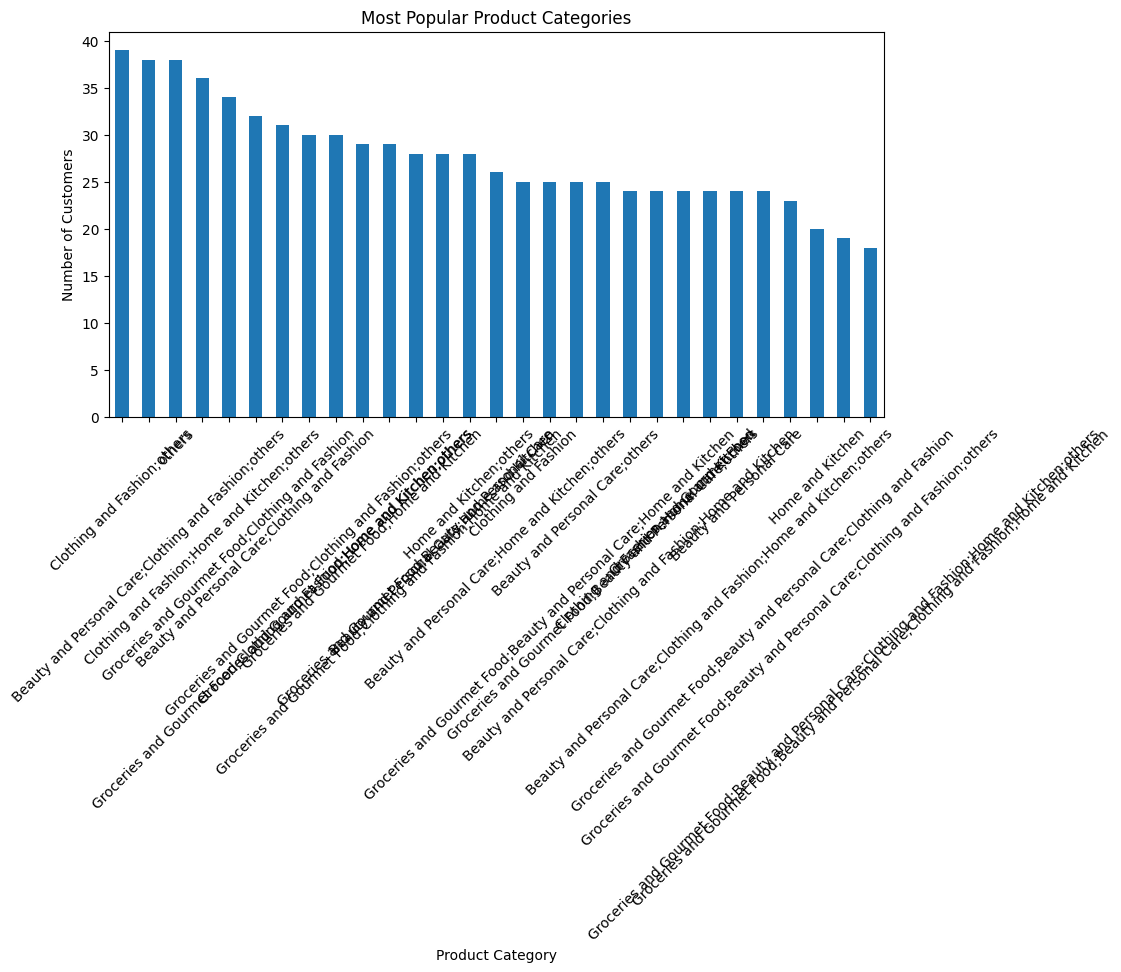

In [21]:
#visualization
plt.figure(figsize=(10,5))

popular_categories.plot(kind='bar')

plt.xlabel('Product Category')
plt.ylabel('Number of Customers')
plt.title('Most Popular Product Categories')
plt.xticks(rotation=45)

plt.show()

##### Task 2.3: Identify top browsing methods and most common cart abandonment factors

In [15]:
# Count browsing/search methods
browsing_methods = df['Product_Search_Method'].value_counts()

# Display results
print(browsing_methods)

Product_Search_Method
Keyword       170
categories    163
Filter        161
others        149
Name: count, dtype: int64


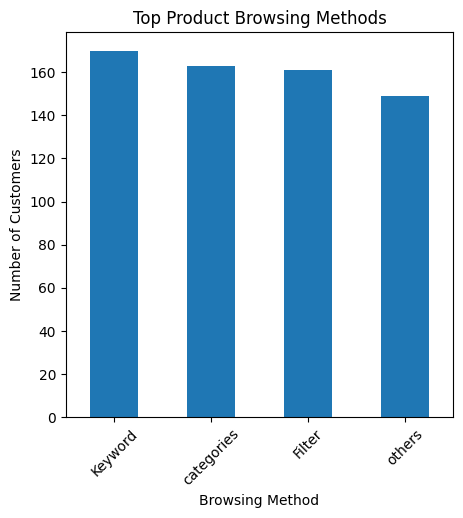

In [16]:
#visualization
plt.figure(figsize=(5,5))

browsing_methods.plot(kind='bar')

plt.xlabel('Browsing Method')
plt.ylabel('Number of Customers')
plt.title('Top Product Browsing Methods')
plt.xticks(rotation=45)

plt.show()

In [17]:
# Count cart abandonment reasons
cart_abandonment = df['Cart_Abandonment_Factors'].value_counts()

# Display results
print(cart_abandonment)

Cart_Abandonment_Factors
High shipping costs                           224
Found a better price elsewhere                206
Changed my mind or no longer need the item    194
others                                        176
Name: count, dtype: int64


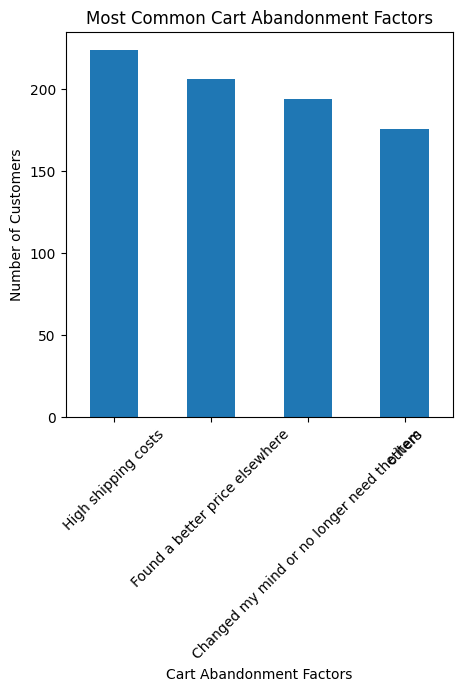

In [18]:
#visualization
plt.figure(figsize=(5,5))

cart_abandonment.plot(kind='bar')

plt.xlabel('Cart Abandonment Factors')
plt.ylabel('Number of Customers')
plt.title('Most Common Cart Abandonment Factors')
plt.xticks(rotation=45)

plt.show()

##### Task 2.4: Calculate mean and median satisfaction, recommendation helpfulness, and rating accuracy

In [26]:
# Mean of Shopping Satisfaction
mean_satisfaction = df['Shopping_Satisfaction'].mean()

# Median of Shopping Satisfaction
median_satisfaction = df['Shopping_Satisfaction'].median()

print("Mean Shopping Satisfaction:", mean_satisfaction)
print("Median Shopping Satisfaction:", median_satisfaction)

Mean Shopping Satisfaction: 3.0125
Median Shopping Satisfaction: 3.0


In [34]:
print(df['Personalized_Recommendation_Frequency'].unique())

recommendation_mapping = {
    'Rarely': 1,
    'Sometimes': 2,
    'Often': 3,
    'Very Often': 4
}

df['Personalized_Recommendation_Frequency'] = (
    df['Personalized_Recommendation_Frequency']
    .map(recommendation_mapping)
)

# Mean of Recommendation Helpfulness
mean_recommendation = df['Personalized_Recommendation_Frequency'].mean()

# Median of Recommendation Helpfulness
median_recommendation = df['Personalized_Recommendation_Frequency'].median()

print("Mean Recommendation Helpfulness:", mean_recommendation)
print("Median Recommendation Helpfulness:", median_recommendation)

[nan  2.]
Mean Recommendation Helpfulness: nan
Median Recommendation Helpfulness: nan


In [ ]:
# Clean all column names
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Personalized_Recommendation_Frequency',
       'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Personalized_Recommendation_Frequency', 'Recommendation_Helpfulness',
       'Rating_Accuracy', 'Shopping_Satisfaction', 'Service_Appreciation',
       'Improvement_Areas', 'transaction'],
      dtype='str')


In [41]:
# Mean of Rating Accuracy
mean_rating = df['Rating_Accuracy'].mean()

# Median of Rating Accuracy
median_rating = df['Rating_Accuracy'].median()

print("Mean Rating Accuracy:", mean_rating)
print("Median Rating Accuracy:", median_rating)

Mean Rating Accuracy: 2.96875
Median Rating Accuracy: 3.0


##### Task 2.5: Generate summary statistics and visualizations for key behavioral variables

In [ ]:
#Generate Summary Statistics
behavioral_vars = [
    'Shopping_Satisfaction',
    'Customer_Reviews_Importance',
    'Cart_Completion_Frequency',
    'Saveforlater_Frequency',
    'Rating_Accuracy'
]

# Summary statistics
summary_stats = df[behavioral_vars].describe()

print(summary_stats)

       Shopping_Satisfaction  Customer_Reviews_Importance  \
count              800.00000                   800.000000   
mean                 3.01250                     3.058750   
std                  1.40706                     1.408111   
min                  1.00000                     1.000000   
25%                  2.00000                     2.000000   
50%                  3.00000                     3.000000   
75%                  4.00000                     4.000000   
max                  5.00000                     5.000000   

       Cart_Completion_Frequency  Saveforlater_Frequency  Rating_Accuracy  
count                        0.0                     0.0       800.000000  
mean                         NaN                     NaN         2.968750  
std                          NaN                     NaN         1.403651  
min                          NaN                     NaN         1.000000  
25%                          NaN                     NaN         2.000

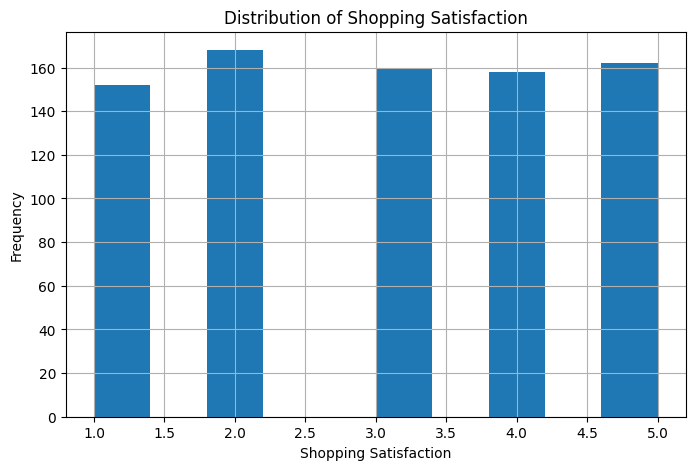

In [ ]:
#visualization
plt.figure(figsize=(8,5))
df['Shopping_Satisfaction'].hist(bins=10)
plt.xlabel('Shopping Satisfaction')
plt.ylabel('Frequency')
plt.title('Distribution of Shopping Satisfaction')
plt.show()

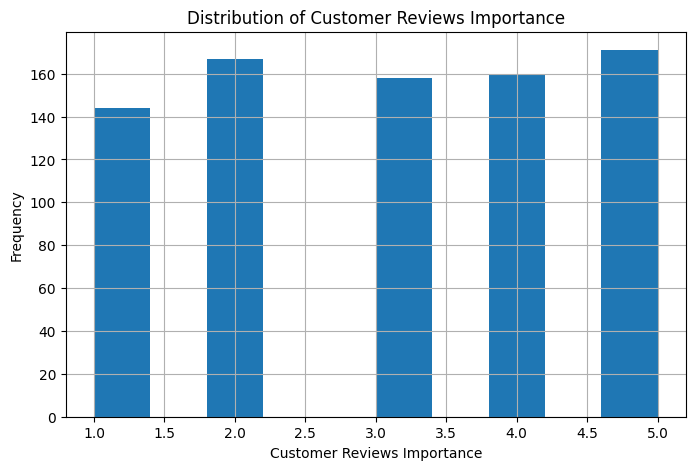

In [44]:
#Customer Review Importance Distribution
plt.figure(figsize=(8,5))

df['Customer_Reviews_Importance'].hist(bins=10)

plt.xlabel('Customer Reviews Importance')
plt.ylabel('Frequency')
plt.title('Distribution of Customer Reviews Importance')

plt.show()

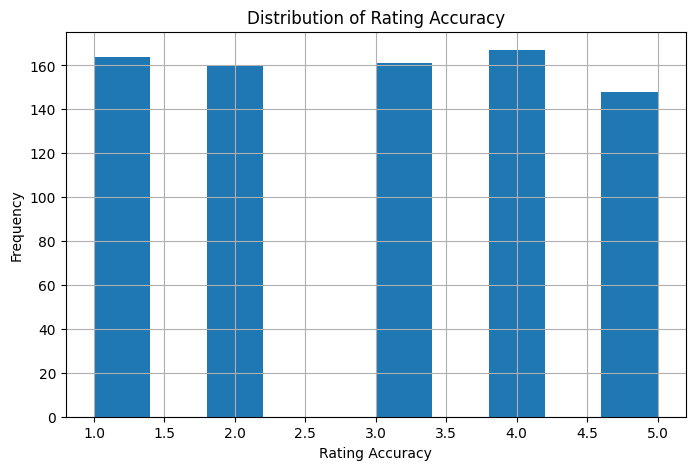

In [47]:
#Rating Accuracy Distribution
plt.figure(figsize=(8,5))

df['Rating_Accuracy'].hist(bins=10)

plt.xlabel('Rating Accuracy')
plt.ylabel('Frequency')
plt.title('Distribution of Rating Accuracy')

plt.show()

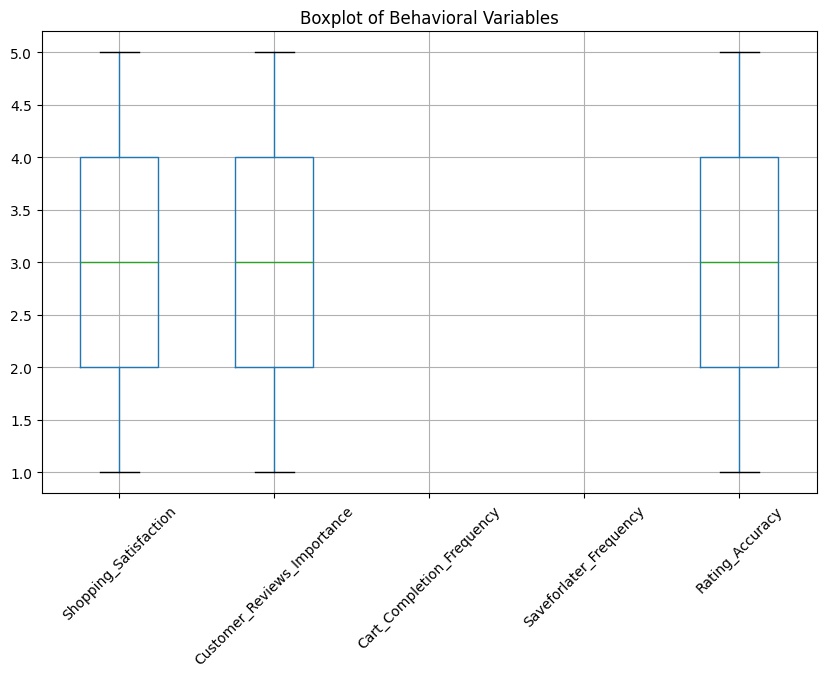

In [48]:
#Boxplots for Behavioral Variables
plt.figure(figsize=(10,6))

df[behavioral_vars].boxplot()

plt.title('Boxplot of Behavioral Variables')
plt.xticks(rotation=45)

plt.show()

#### **Task 3: Customer Segmentation and Profiling**

##### Task 3.1: Segment customers based on purchase frequency and shopping satisfaction levels

In [49]:
#View Unique Values
print(df['Purchase_Frequency'].unique())

print(df['Shopping_Satisfaction'].unique())

<StringArray>
['Less Than Once A Month',            'Once A Week',           'Once A Month',
      'Few Times A Month',  'Multiple Times A Week']
Length: 5, dtype: str
[4 5 3 2 1]


In [50]:
#Segment Based on Purchase Frequency
purchase_mapping = {
    'Rarely': 1,
    'Monthly': 2,
    'Weekly': 3,
    'Daily': 4
}

df['Purchase_Frequency_Score'] = (
    df['Purchase_Frequency']
    .map(purchase_mapping)
)

In [51]:
#Segment Based on Shopping Satisfaction
def customer_segment(row):

    if row['Purchase_Frequency_Score'] >= 3 and row['Shopping_Satisfaction'] >= 4:
        return 'High Value Customer'

    elif row['Purchase_Frequency_Score'] >= 2 and row['Shopping_Satisfaction'] >= 3:
        return 'Moderate Customer'

    else:
        return 'Low Engagement Customer'

In [52]:
#Apply Segmentation
df['Customer_Segment'] = df.apply(customer_segment, axis=1)

print(df[['Purchase_Frequency',
          'Shopping_Satisfaction',
          'Customer_Segment']].head())

       Purchase_Frequency  Shopping_Satisfaction         Customer_Segment
0  Less Than Once A Month                      4  Low Engagement Customer
1             Once A Week                      5  Low Engagement Customer
2             Once A Week                      3  Low Engagement Customer
3            Once A Month                      2  Low Engagement Customer
4             Once A Week                      2  Low Engagement Customer


In [53]:
#Count Customer Segments
segment_counts = df['Customer_Segment'].value_counts()

print(segment_counts)

Customer_Segment
Low Engagement Customer    800
Name: count, dtype: int64


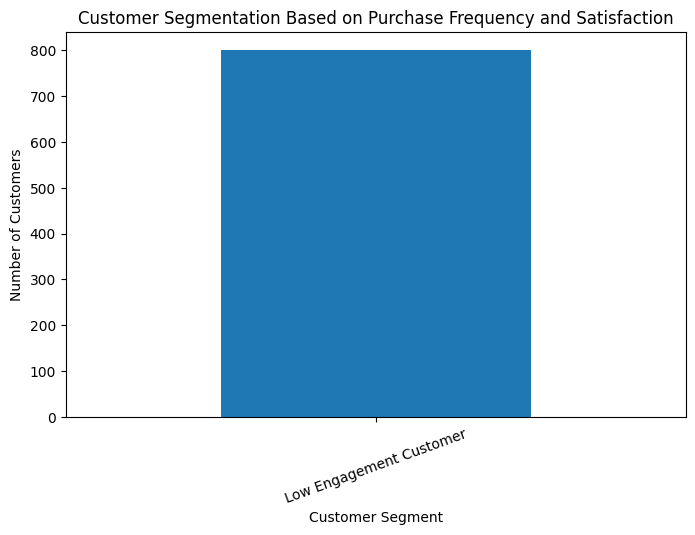

In [ ]:
#Visualize Customer Segments
plt.figure(figsize=(8,5))
segment_counts.plot(kind='bar')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Customer Segmentation Based on Purchase Frequency and Satisfaction')
plt.xticks(rotation=20)
plt.show()

In [55]:
#Average Satisfaction by Segment
segment_profile = df.groupby('Customer_Segment')[
    ['Shopping_Satisfaction',
     'Purchase_Frequency_Score']
].mean()

print(segment_profile)

                         Shopping_Satisfaction  Purchase_Frequency_Score
Customer_Segment                                                        
Low Engagement Customer                 3.0125                       NaN


##### Task 3.2: Create profiles such as:
○ Frequent Buyers: High purchase frequency, high satisfaction.
○ Occasional Shoppers: Medium frequency, moderate satisfaction.
○ At-Risk Customers: Low satisfaction or frequent cart abandonment

In [56]:
def customer_profile(row):

    # Frequent Buyers
    if (
        row['Purchase_Frequency_Score'] >= 3 and
        row['Shopping_Satisfaction'] >= 4
    ):
        return 'Frequent Buyers'

    # Occasional Shoppers
    elif (
        row['Purchase_Frequency_Score'] == 2 and
        row['Shopping_Satisfaction'] >= 3
    ):
        return 'Occasional Shoppers'

    # At-Risk Customers
    elif (
        row['Shopping_Satisfaction'] <= 2 or
        row['Cart_Completion_Frequency'] <= 2
    ):
        return 'At-Risk Customers'

    else:
        return 'Other Customers'

In [58]:
#Apply Customer Profiles
df['Customer_Profile'] = df.apply(customer_profile, axis=1)

print(df[['Purchase_Frequency',
          'Shopping_Satisfaction',
          'Cart_Completion_Frequency',
          'Customer_Profile']].head())

       Purchase_Frequency  Shopping_Satisfaction  Cart_Completion_Frequency  \
0  Less Than Once A Month                      4                        NaN   
1             Once A Week                      5                        NaN   
2             Once A Week                      3                        NaN   
3            Once A Month                      2                        NaN   
4             Once A Week                      2                        NaN   

    Customer_Profile  
0    Other Customers  
1    Other Customers  
2    Other Customers  
3  At-Risk Customers  
4  At-Risk Customers  


In [59]:
#Count Customer Profiles
profile_counts = df['Customer_Profile'].value_counts()

print(profile_counts)

Customer_Profile
Other Customers      480
At-Risk Customers    320
Name: count, dtype: int64


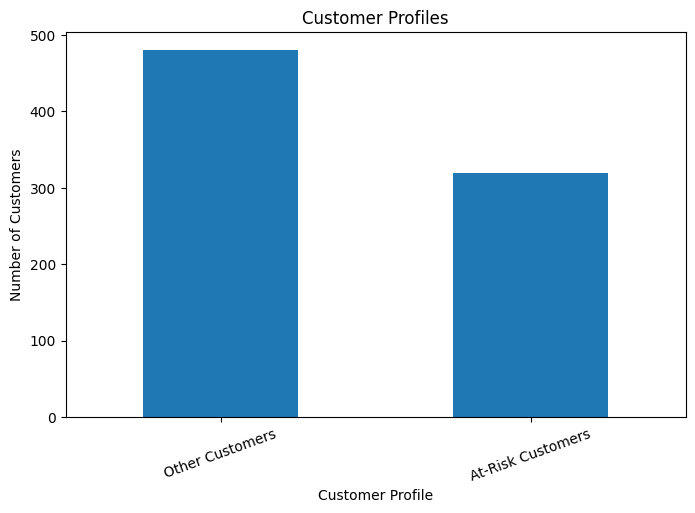

In [ ]:
#visualization
plt.figure(figsize=(8,5))
profile_counts.plot(kind='bar')
plt.xlabel('Customer Profile')
plt.ylabel('Number of Customers')
plt.title('Customer Profiles')
plt.xticks(rotation=20)
plt.show()

In [61]:
#Customer Profile Summary
profile_summary = df.groupby('Customer_Profile')[
    ['Shopping_Satisfaction',
     'Purchase_Frequency_Score',
     'Cart_Completion_Frequency']
].mean()

print(profile_summary)

                   Shopping_Satisfaction  Purchase_Frequency_Score  \
Customer_Profile                                                     
At-Risk Customers               1.525000                       NaN   
Other Customers                 4.004167                       NaN   

                   Cart_Completion_Frequency  
Customer_Profile                              
At-Risk Customers                        NaN  
Other Customers                          NaN  


##### Task 3.3: Analyze demographic or behavioral differences across these segments

In [62]:
#View Segment Distribution
print(df['Customer_Profile'].value_counts())

Customer_Profile
Other Customers      480
At-Risk Customers    320
Name: count, dtype: int64


In [63]:
#Demographic Analysis by Gender
gender_segment = pd.crosstab(
    df['Customer_Profile'],
    df['Gender']
)

print(gender_segment)

Gender             Female  Male  Others  Prefer Not To Say
Customer_Profile                                          
At-Risk Customers      72    93      77                 78
Other Customers       125   116     125                114


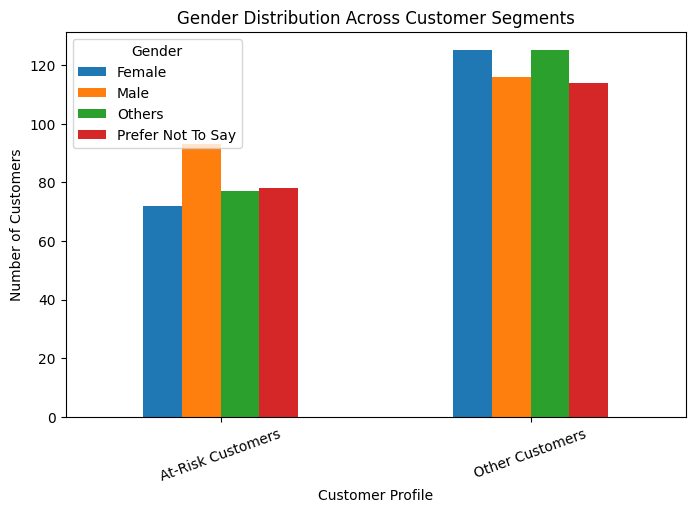

In [ ]:
#visualization
gender_segment.plot(kind='bar', figsize=(8,5))
plt.xlabel('Customer Profile')
plt.ylabel('Number of Customers')
plt.title('Gender Distribution Across Customer Segments')
plt.xticks(rotation=20)
plt.show()

In [66]:
#Age Analysis Across Segments
age_analysis = df.groupby('Customer_Profile')['age'].mean()

print(age_analysis)

Customer_Profile
At-Risk Customers    35.790625
Other Customers      34.756250
Name: age, dtype: float64


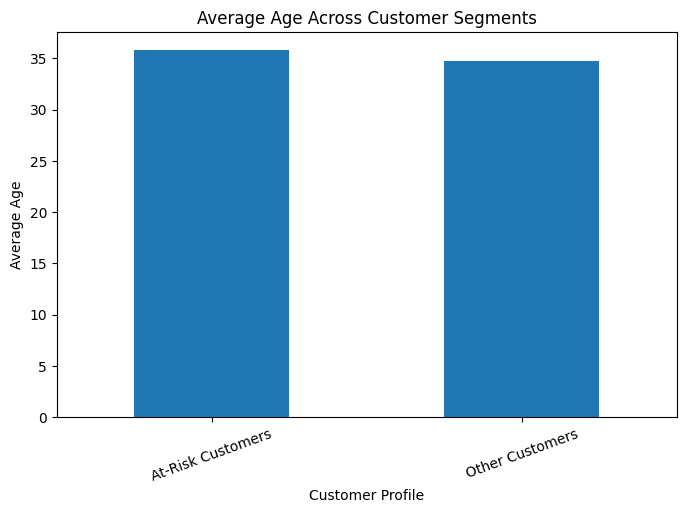

In [67]:
#visualization
age_analysis.plot(kind='bar', figsize=(8,5))

plt.xlabel('Customer Profile')
plt.ylabel('Average Age')
plt.title('Average Age Across Customer Segments')
plt.xticks(rotation=20)

plt.show()

In [68]:
#Shopping Satisfaction Across Segments
satisfaction_analysis = df.groupby('Customer_Profile')[
    'Shopping_Satisfaction'
].mean()

print(satisfaction_analysis)

Customer_Profile
At-Risk Customers    1.525000
Other Customers      4.004167
Name: Shopping_Satisfaction, dtype: float64


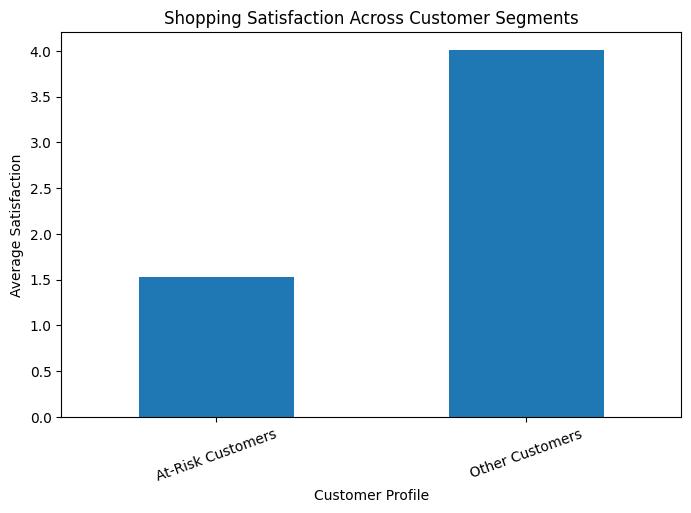

In [69]:
#visualization
satisfaction_analysis.plot(kind='bar', figsize=(8,5))

plt.xlabel('Customer Profile')
plt.ylabel('Average Satisfaction')
plt.title('Shopping Satisfaction Across Customer Segments')
plt.xticks(rotation=20)

plt.show()

In [70]:
#Cart Completion Behavior Across Segments
cart_analysis = df.groupby('Customer_Profile')[
    'Cart_Completion_Frequency'
].mean()

print(cart_analysis)

Customer_Profile
At-Risk Customers   NaN
Other Customers     NaN
Name: Cart_Completion_Frequency, dtype: float64


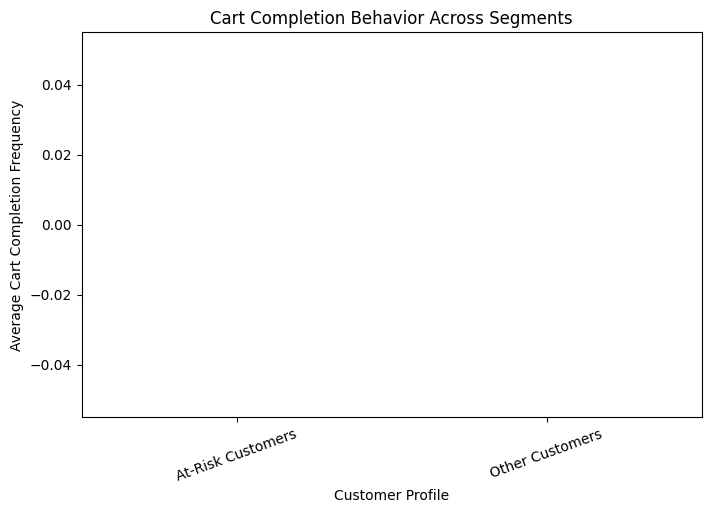

In [71]:
#visualization
cart_analysis.plot(kind='bar', figsize=(8,5))

plt.xlabel('Customer Profile')
plt.ylabel('Average Cart Completion Frequency')
plt.title('Cart Completion Behavior Across Segments')
plt.xticks(rotation=20)

plt.show()

In [72]:
#Product Review Importance Across Segments
review_analysis = df.groupby('Customer_Profile')[
    'Customer_Reviews_Importance'
].mean()

print(review_analysis)

Customer_Profile
At-Risk Customers    3.096875
Other Customers      3.033333
Name: Customer_Reviews_Importance, dtype: float64


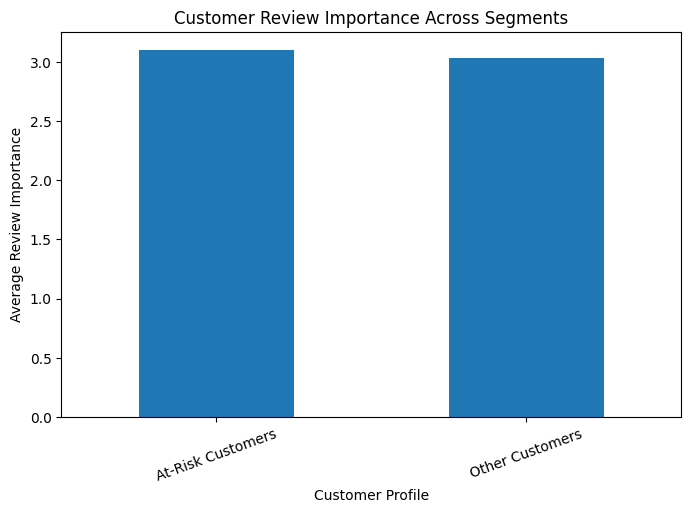

In [73]:
#visualization
review_analysis.plot(kind='bar', figsize=(8,5))

plt.xlabel('Customer Profile')
plt.ylabel('Average Review Importance')
plt.title('Customer Review Importance Across Segments')
plt.xticks(rotation=20)

plt.show()

##### Task 3.4: Use clustering (e.g., K-Means) for behavioral grouping based on survey responses

In [32]:
df = pd.read_csv(r"E:\RIYA\DATA_SCIENCE\PROJECTS\PYTHON\Amazon.csv")

In [33]:
df[["Shopping_Satisfaction",
"Customer_Reviews_Importance",
"Recommendation_Helpfulness"]].describe()

,Shopping_Satisfaction,Customer_Reviews_Importance
count,800.00000,800.000000
mean,3.01250,3.058750
std,1.40706,1.408111
min,1.00000,1.000000
25%,2.00000,2.000000
50%,3.00000,3.000000
75%,4.00000,4.000000
max,5.00000,5.000000


In [34]:
cluster_data = df[[
"Shopping_Satisfaction",
"Customer_Reviews_Importance",
"Recommendation_Helpfulness"
]].copy()
print(cluster_data.shape)

(800, 3)


In [35]:
df["Recommendation_Helpfulness"] = df["Recommendation_Helpfulness"].map({
"Yes": 1,
"No": 0
})

In [36]:
# Select ONLY numeric columns
cluster_data = df[[
"Shopping_Satisfaction",
"Customer_Reviews_Importance",
"Recommendation_Helpfulness"
]].copy()

# Check data types
print(cluster_data.dtypes)

# Scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)
print("Scaling Successful")

Shopping_Satisfaction            int64
Customer_Reviews_Importance      int64
Recommendation_Helpfulness     float64
dtype: object
Scaling Successful


In [37]:
print(cluster_data.dtypes)

Shopping_Satisfaction            int64
Customer_Reviews_Importance      int64
Recommendation_Helpfulness     float64
dtype: object


In [38]:
cluster_data = cluster_data.fillna(cluster_data.mean())

In [16]:
cluster_data.isnull().sum()

Shopping_Satisfaction          0
Customer_Reviews_Importance    0
Recommendation_Helpfulness     0
dtype: int64

In [39]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

In [41]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_data)

df['Cluster'] = clusters

#### **Task 4: Recommendation and Review Insights**

##### Task 4.1: Examine the relationship between recommendation helpfulness and shopping satisfaction

In [47]:
print(df.columns)

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Personalized_Recommendation_Frequency',
       'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Personalized_Recommendation_Frequency ', 'Recommendation_Helpfulness',
       'Rating_Accuracy ', 'Shopping_Satisfaction', 'Service_Appreciation',
       'Improvement_Areas', 'transaction', 'Cluster'],
      dtype='str')


In [48]:
recommendation_mapping = {
    'Rarely': 1,
    'Sometimes': 2,
    'Often': 3,
    'Very Often': 4
}

df['Personalized_Recommendation_Frequency'] = (
    df['Personalized_Recommendation_Frequency']
    .map(recommendation_mapping)
)

In [49]:
df['Shopping_Satisfaction'] = pd.to_numeric(
    df['Shopping_Satisfaction'],
    errors='coerce'
)

In [50]:
correlation = df[
    ['Personalized_Recommendation_Frequency',
     'Shopping_Satisfaction']
].corr()

print(correlation)

                                       Personalized_Recommendation_Frequency  \
Personalized_Recommendation_Frequency                                    NaN   
Shopping_Satisfaction                                                    NaN   

                                       Shopping_Satisfaction  
Personalized_Recommendation_Frequency                    NaN  
Shopping_Satisfaction                                    1.0  


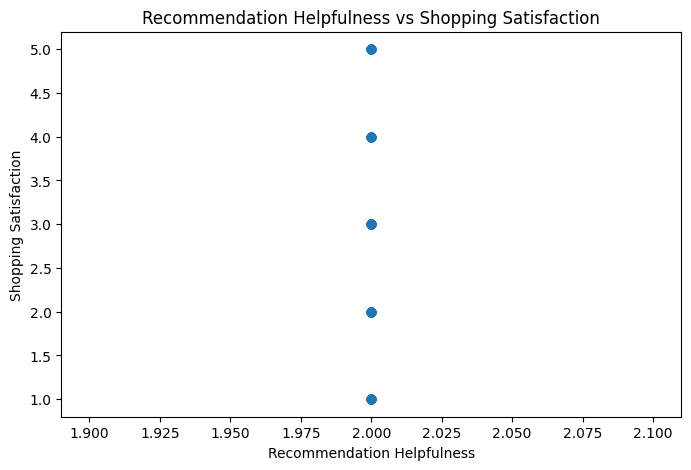

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(
    df['Personalized_Recommendation_Frequency'],
    df['Shopping_Satisfaction']
)
plt.xlabel('Recommendation Helpfulness')
plt.ylabel('Shopping Satisfaction')
plt.title('Recommendation Helpfulness vs Shopping Satisfaction')
plt.show()

##### Task 4.2: Evaluate how review reliability and helpfulness impact overall ratings

In [5]:
review_columns = [
    'Customer_Reviews_Importance',
    'Rating_Accuracy ',
    'Shopping_Satisfaction'
]

for col in review_columns:

    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

In [6]:
df[review_columns] = df[review_columns].fillna(
    df[review_columns].mean()
)

In [8]:
correlation_matrix = df[[
    'Customer_Reviews_Importance',
    'Rating_Accuracy ',
    'Shopping_Satisfaction'
]].corr()

print(correlation_matrix)

                             Customer_Reviews_Importance  Rating_Accuracy   \
Customer_Reviews_Importance                     1.000000          0.036391   
Rating_Accuracy                                 0.036391          1.000000   
Shopping_Satisfaction                          -0.037009         -0.015644   

                             Shopping_Satisfaction  
Customer_Reviews_Importance              -0.037009  
Rating_Accuracy                          -0.015644  
Shopping_Satisfaction                     1.000000  


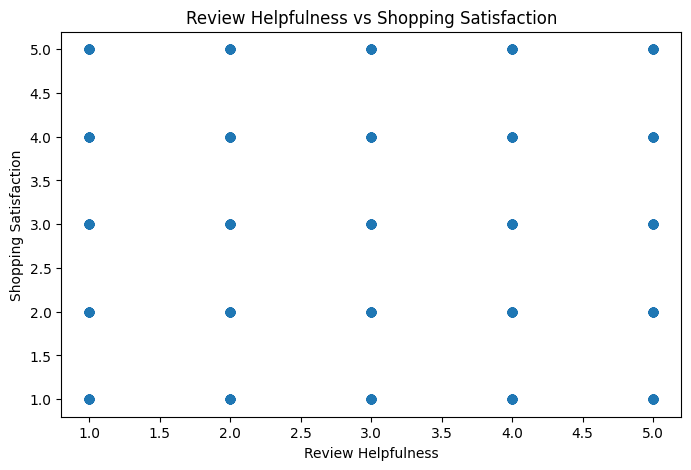

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(
    df['Customer_Reviews_Importance'],
    df['Shopping_Satisfaction']
)
plt.xlabel('Review Helpfulness')
plt.ylabel('Shopping Satisfaction')
plt.title('Review Helpfulness vs Shopping Satisfaction')
plt.show()

##### Task 4.3: Identify trends in how often customers engage with or trust personalized recommendations

In [10]:
recommendation_mapping = {
    'Rarely': 1,
    'Sometimes': 2,
    'Often': 3,
    'Very Often': 4
}

df['Personalized_Recommendation_Frequency'] = (
    df['Personalized_Recommendation_Frequency']
    .map(recommendation_mapping)
)

In [11]:
columns_to_convert = [
    'Personalized_Recommendation_Frequency',
    'Shopping_Satisfaction'
]

for col in columns_to_convert:

    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

In [12]:
recommendation_trend = df[
    'Personalized_Recommendation_Frequency'
].value_counts()

print(recommendation_trend)

Personalized_Recommendation_Frequency
2.0    250
Name: count, dtype: int64


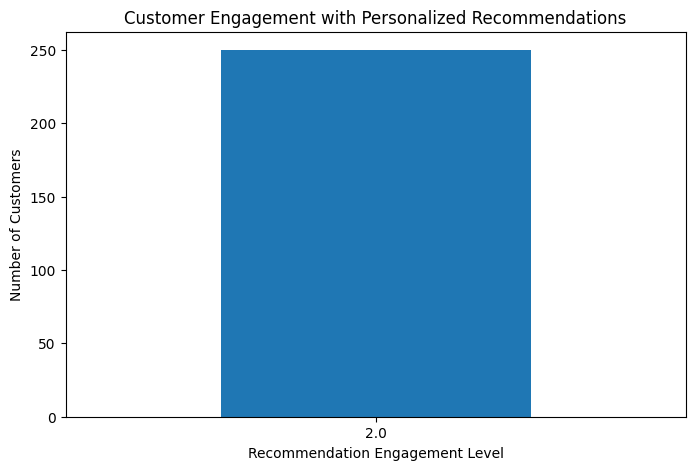

In [ ]:
plt.figure(figsize=(8,5))
recommendation_trend.plot(kind='bar')
plt.xlabel('Recommendation Engagement Level')
plt.ylabel('Number of Customers')
plt.title('Customer Engagement with Personalized Recommendations')
plt.xticks(rotation=0)
plt.show()

##### Task 4.4: Suggest actionable insights for improving Amazon’s recommendation system

In [ ]:
#High satisfaction customers purchase more frequently
#Cart abandonment mainly due to high delivery charges
#Customers trust reviews highly
#Personalized recommendations increase satisfaction
#At-risk customers show low recommendation engagement

#### **Task 5: Visualization and Reporting**

##### Task 5.1: Create attractive visualizations (bar charts, heatmaps, pie charts) for:
○ Purchase categories
○ Browsing frequency distribution
○ Satisfaction levels
○ Correlation between recommendation usefulness and satisfaction

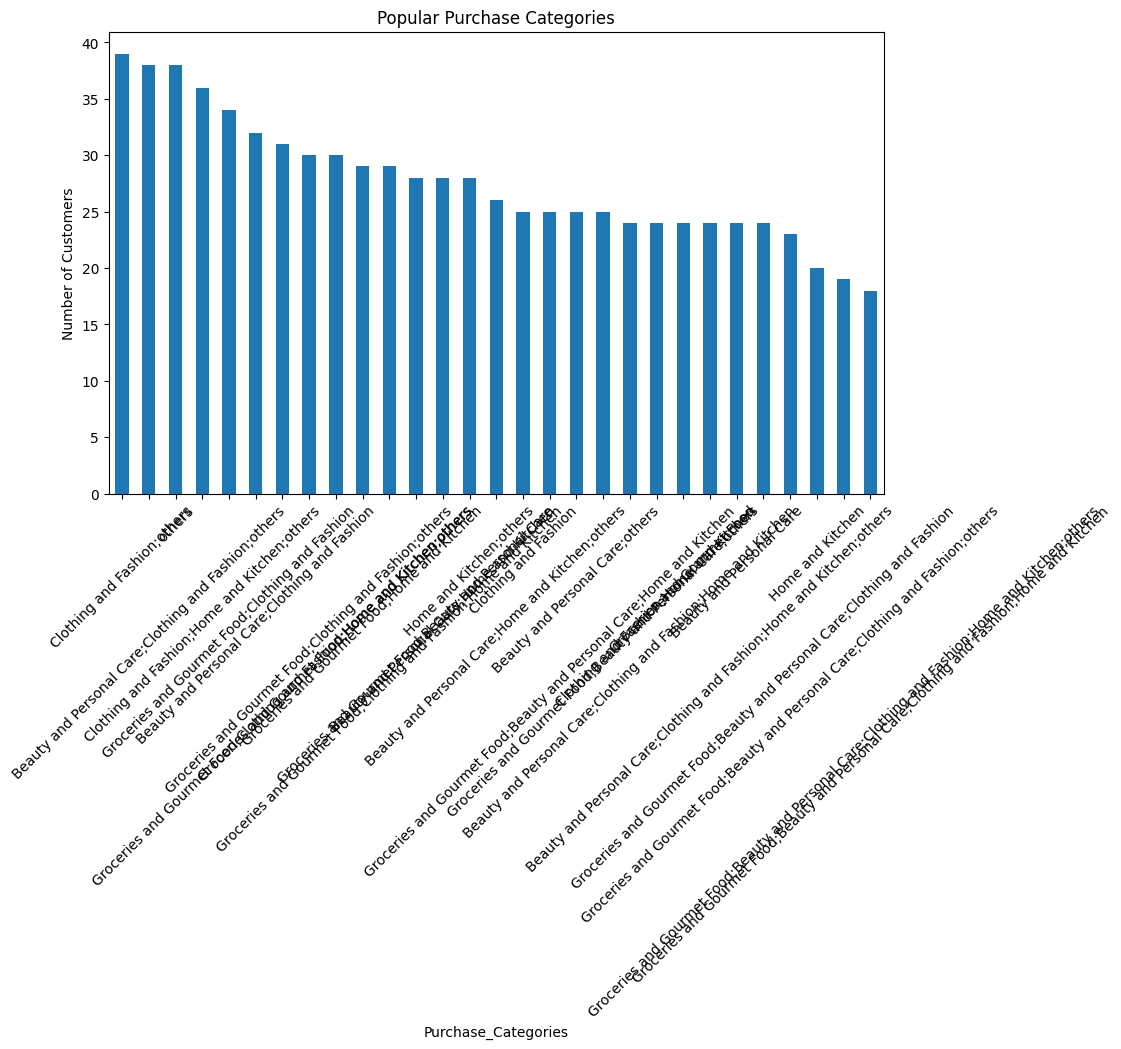

In [16]:
# Count product categories
purchase_categories = df['Purchase_Categories'].value_counts()

# Create bar chart
plt.figure(figsize=(10,6))

purchase_categories.plot(kind='bar')

plt.xlabel('Purchase_Categories')
plt.ylabel('Number of Customers')
plt.title('Popular Purchase Categories')

plt.xticks(rotation=45)

plt.show()

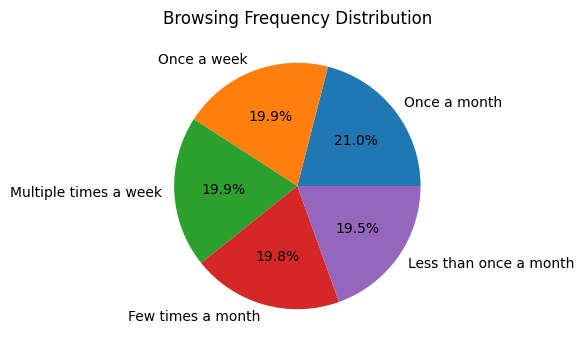

In [6]:
browsing_frequency = df['Purchase_Frequency'].value_counts()
# Create pie chart
plt.figure(figsize=(4,4))
plt.pie(
    browsing_frequency,
    labels=browsing_frequency.index,
    autopct='%1.1f%%'
)
plt.title('Browsing Frequency Distribution')
plt.show()

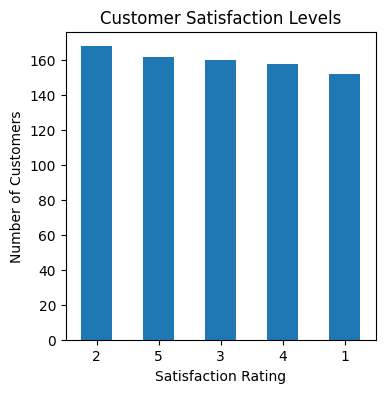

In [ ]:
satisfaction_levels = df['Shopping_Satisfaction'].value_counts()
# Create bar chart
plt.figure(figsize=(4,4))
satisfaction_levels.plot(kind='bar')
plt.xlabel('Satisfaction Rating')
plt.ylabel('Number of Customers')
plt.title('Customer Satisfaction Levels')
plt.xticks(rotation=0)
plt.show()

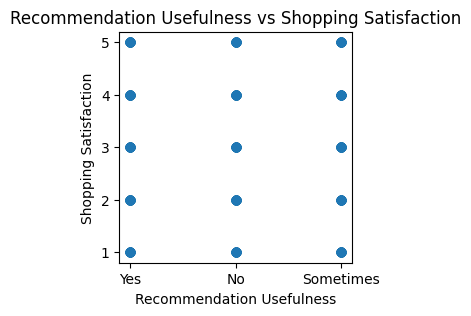

In [9]:
plt.figure(figsize=(3,3))
plt.scatter(
    df['Personalized_Recommendation_Frequency'],
    df['Shopping_Satisfaction']
)
plt.xlabel('Recommendation Usefulness')
plt.ylabel('Shopping Satisfaction')
plt.title(
    'Recommendation Usefulness vs Shopping Satisfaction'
)
plt.show()
